In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('datasets/toxic-comments.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [5]:
df.shape

(159571, 8)

In [6]:
comments = df.sum(numeric_only=True)

In [7]:
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [8]:
comments.sum()

np.int64(35098)

<BarContainer object of 6 artists>

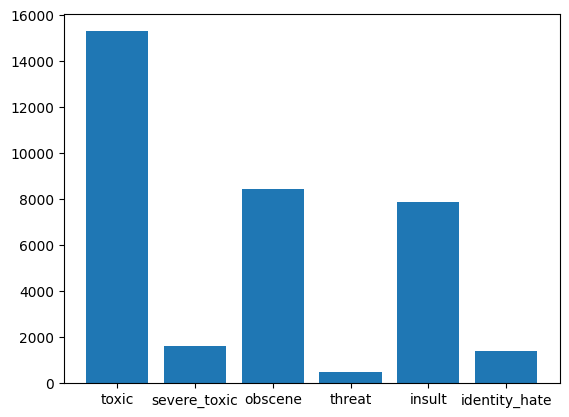

In [9]:
plt.bar(comments.index, comments)

([<matplotlib.patches.Wedge at 0x1766dc51b40>,
 [Text(0.22052288704922637, 1.077668620814151, 'toxic'),
  Text(-1.0627685748125797, 0.28376567162156585, 'severe_toxic'),
  Text(-0.8835448513040229, -0.655246896775675, 'obscene'),
  Text(-0.1465640005926253, -1.0901921820166778, 'threat'),
  Text(0.6339462415225215, -0.8989505897764732, 'insult'),
  Text(1.0913127724060203, -0.13797257982470842, 'identity_hate')],
 [Text(0.12028521111775983, 0.5878192477168096, '43.58%'),
  Text(-0.5796919498977706, 0.154781275429945, '4.54%'),
  Text(-0.48193355525673975, -0.35740739824127726, '24.07%'),
  Text(-0.07994400032325015, -0.594650281100006, '1.36%'),
  Text(0.34578885901228446, -0.4903366853326217, '22.44%'),
  Text(0.5952615122214656, -0.07525777081347731, '4.00%')])

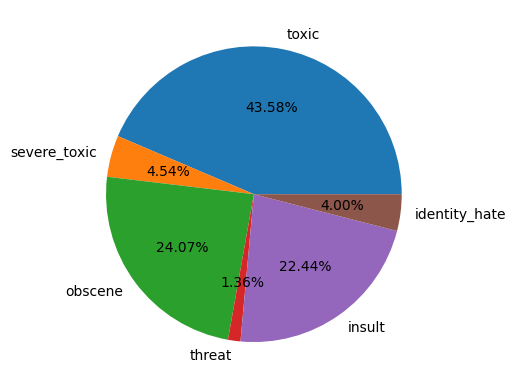

In [10]:
plt.pie(comments, labels=comments.index, autopct='%2.2f%%')

In [13]:
total = df.sum(numeric_only=True, axis=1)
total

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [14]:
sum(total !=0)

16225

In [15]:
sum(total ==0)

143346

In [16]:
newdf = pd.DataFrame({
    'neutral':[(sum(total ==0))],
    'toxic': [(sum(total !=0))]
})
newdf

,neutral,toxic
0,143346,16225


In [17]:
newdf.T

,0
neutral,143346
toxic,16225


#### Data Cleaning

In [21]:
import re

In [22]:

def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-z0-9]+',' ',text)
    return text

In [23]:
sample_text = 'Hello, how are you?'

In [25]:
clean_text(sample_text)

'hello how are you '

In [27]:
comments = df['comment_text']

In [28]:
labels = df.drop(['id', 'comment_text'], axis=1)

In [29]:
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [30]:
comments_text = comments.apply(clean_text)

In [31]:
comments_text

0         explanation why the edits made under my userna...
1         d aww he matches this background colour i m se...
2         hey man i m really not trying to edit war it s...
3          more i can t make any real suggestions on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566     and for the second time of asking when your v...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm theres no actual article for prost...
159569    and it looks like it was actually you who put ...
159570     and i really don t think you understand i cam...
Name: comment_text, Length: 159571, dtype: object

#### Prepare the Input Data

In [32]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU
from sklearn.model_selection import train_test_split

In [33]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comments_text)
sequences = tokenizer.texts_to_sequences(comments_text)
padded = pad_sequences(sequences, maxlen=200, padding='post')

In [34]:
padded.shape

(159571, 200)

In [35]:
padded

array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [  48,  732,   25, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]],
      shape=(159571, 200), dtype=int32)

#### Cross-Validation

In [38]:


x_train, x_test, y_train, y_test = train_test_split(
    padded, labels, random_state=0, test_size=0.2
)


In [40]:
x_train.shape, y_train.shape
x_test.shape, y_test.shape

((31915, 200), (31915, 6))

#### Build the Model

In [41]:
model = Sequential()

model.add(Embedding(5000, 100, input_length=200))
model.add(GRU(128))
model.add(Dense(6,activation='sigmoid'))

c:\Users\PGCP-AI\.conda\envs\DNN_AI_26\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [44]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

#### Train the Model

In [45]:
model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 669s 167ms/step - accuracy: 0.9828 - loss: 0.0675 - val_accuracy: 0.9797 - val_loss: 0.0505
Epoch 2/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 660s 165ms/step - accuracy: 0.9812 - loss: 0.0470 - val_accuracy: 0.9615 - val_loss: 0.0496
Epoch 3/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 667s 167ms/step - accuracy: 0.9562 - loss: 0.0422 - val_accuracy: 0.9803 - val_loss: 0.0499
